# 3D Density Field Analysis

Analysis notebook for **`DensityField`** — 3D matter density snapshots on a regular mesh.

In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"  # must be before any JAX import

import sys
from pathlib import Path

import jax
import jax.numpy as jnp
import jax_cosmo as jc
import jax_fli as jfli
import matplotlib.pyplot as plt
import numpy as np

from utils import set_jcap_style
set_jcap_style()

In [ ]:
# ===== CONFIGURE HERE =====

PATHS = ["/home/wassim/Projects/NBody/jax-fli-result/results/WIP/3D_SIM/3D_SIM_M768x768x768_B2000x2000x2000_STEPS50_c0.2589_S80.8159_s0.parquet"]
LABELS = ["dens_2"]

NONLINEAR_FN = "halofit"   # "halofit" or "linear"
CMAP = "magma"             # colormap for projected maps
LOG_SCALE = True           # apply log1p to projected density for display

# ===== END CONFIGURATION =====

## 1. Load & Inspect

In [8]:
catalogs = []
for path, label in zip(PATHS, LABELS):
    cat = jfli.io.Catalog.from_parquet(path)
    fld = cat.field[0]
    cos = cat.cosmology[0]
    catalogs.append({"label": label, "cat": cat, "field": fld, "cosmo": cos})
    print(f"Loaded  : {label}")
    print(f"  path  : {path}")
    print(f"  type  : {type(fld).__name__}")
    print()

fld0 = catalogs[0]["field"]
cos0 = catalogs[0]["cosmo"]


print("=== Reference field ===")
print(fld0)
print("=== Reference cosmology ===")
print(cos0)

Loaded  : dens_2
  path  : /home/wassim/Projects/NBody/jax-fli-result/results/WIP/3D_SIM/3D_SIM_M768x768x768_B2000x2000x2000_STEPS50_c0.2589_S80.8159_s0.parquet
  type  : DensityField

=== Reference field ===
DensityField(array  = Array(768, 768, 768)
, dtype  = float32,   mesh_size         =(768, 768, 768),   box_size          =(2000.0, 2000.0, 2000.0),   observer_position =(0.5, 0.5, 0.5),   field_sharding    =None,   halo_size         =(48, 384),   nside             =None,   flatsky_npix      =None,   field_size        =(10.0, 10.0),   status            =LIGHTCONE,   unit              =DENSITY,   name              =np.str_('3D_SIM_M768x768x768_B2000x2000x2000_STEPS50_c0.2589_S80.8159_s0'))
=== Reference cosmology ===
Cosmological parameters: 
    h:        0.6774 
    Omega_b:  0.0486 
    Omega_c:  0.2589 
    Omega_k:  0.0 
    w0:       -1.0 
    wa:       0.0 
    n:        0.9667 
    sigma8:   0.8159 
    Omega_nu: 0.0


## 2. Field Projections

Mean projection along the z-axis per snapshot.  
`LOG_SCALE = True` applies `log1p` to enhance contrast in underdense regions.

/home/wassim/micromamba/envs/ffi11/lib/python3.11/dataclasses.py:1501: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return obj.__class__(**changes)


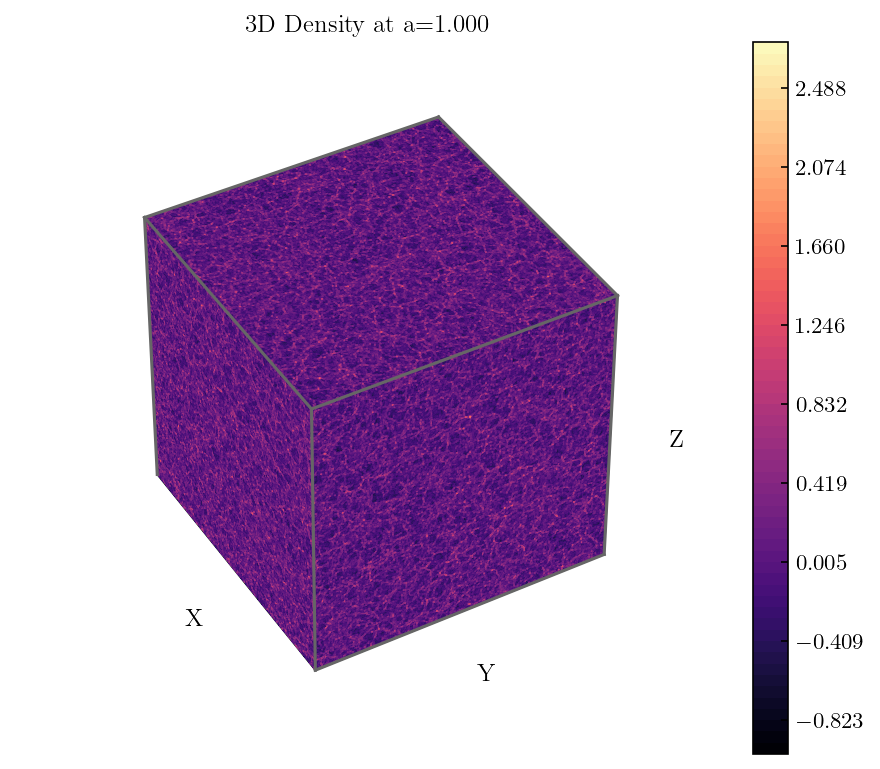

In [10]:
fld0.apply_fn(lambda x : jnp.log10(x + 0.1)).show()

/home/wassim/micromamba/envs/ffi11/lib/python3.11/dataclasses.py:1501: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return obj.__class__(**changes)
/home/wassim/Projects/NBody/jax-fli/src/jax_fli/_src/base/_core.py:323: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return cls(


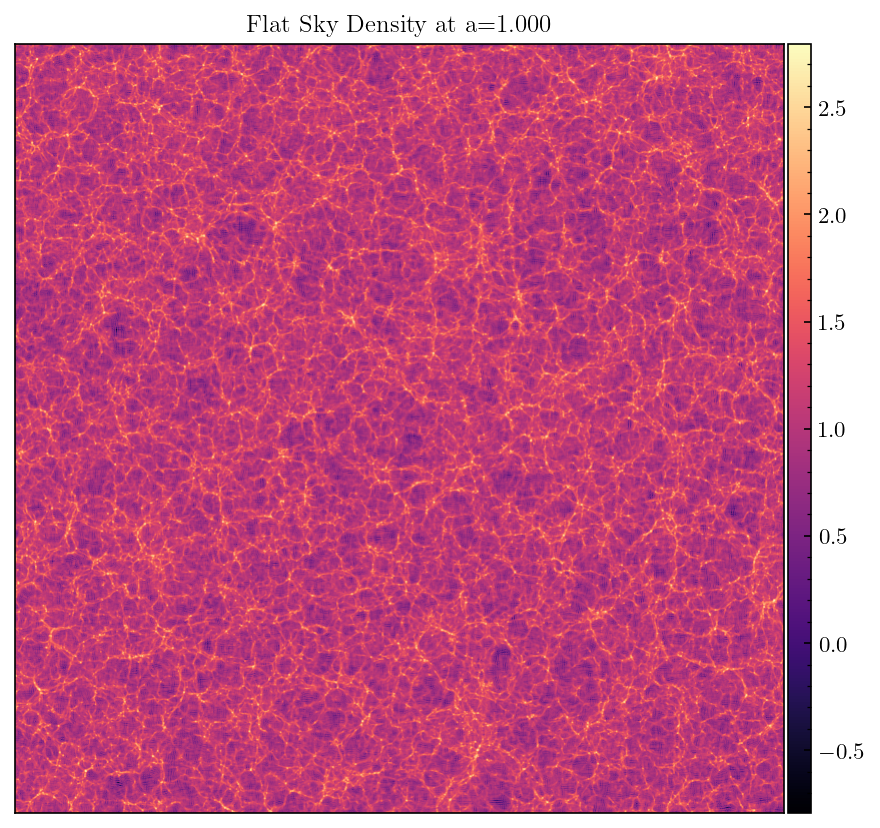

In [11]:
fld0.project(nz_slices=16).apply_fn(lambda x : jnp.log10(x + 0.1)).show()

## 3. 3D Matter Power Spectrum P(k)

dens_2: P(k) shape = (190,)


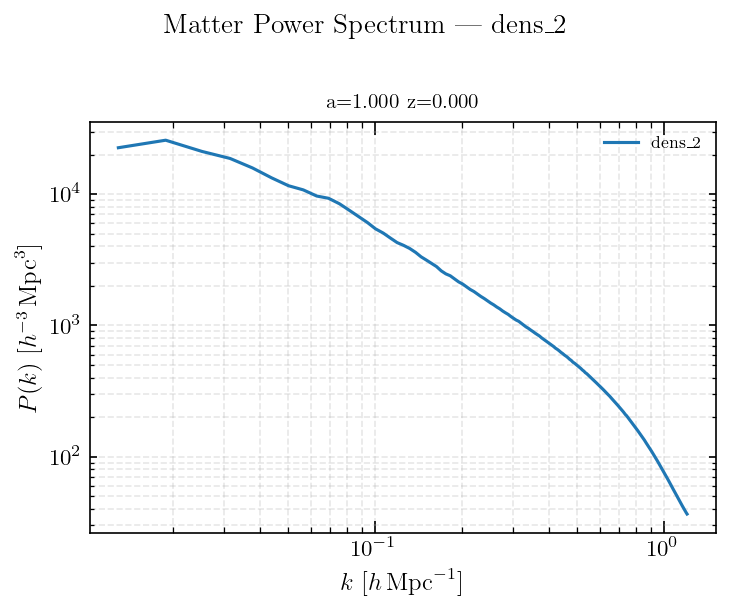

In [12]:
all_pks = []
for entry in catalogs:
    pk = entry["field"].power()
    all_pks.append(pk)
    print(f"{entry['label']}: P(k) shape = {np.asarray(pk.array).shape}")

pk0     = all_pks[0]
k       = np.asarray(pk0.wavenumber)   # (n_k,)
pk0_arr = np.asarray(pk0.array)        # (n_snaps, n_k) or (n_k,)
if pk0_arr.ndim == 1:
    pk0_arr = pk0_arr[np.newaxis]

fig, axes = plt.subplots(1, n_snaps,
                         figsize=(5 * n_snaps, 4),
                         squeeze=False)
for i in range(n_snaps):
    ax  = axes[0, i]
    pk_i = pk0_arr[i] if pk0_arr.shape[0] > 1 else pk0_arr[0]
    ax.loglog(k, pk_i, color="tab:blue", lw=1.5, label=catalogs[0]["label"])
    ax.grid(True, which="both", ls="--", alpha=0.3)
    ax.set_xlabel(r"$k\;[h\,\mathrm{Mpc}^{-1}]$")
    ax.set_ylabel(r"$P(k)\;[h^{-3}\,\mathrm{Mpc}^3]$")
    a_i = float(sf[i]) if i < len(sf) else 1.0
    z_i = float(zs[i]) if i < len(zs) else 0.0
    ax.set_title(f"a={a_i:.3f}  z={z_i:.3f}", fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle(f"Matter Power Spectrum — {catalogs[0]['label']}", y=1.01)
fig.tight_layout()
# fig.savefig("output/density3d_pk.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Theory Comparison (Halofit)

Theory P(k) from `jax_cosmo` using the cosmology stored in the parquet.  
The vertical dashed line marks the Nyquist frequency $k_\mathrm{Nyq} = \pi N / L$.

In [13]:
nl_fn = jc.power.halofit if NONLINEAR_FN == "halofit" else jc.power.linear

print(f"Computing theory P(k) [{NONLINEAR_FN}] for {n_snaps} snapshot(s)...")
theory_pks = []
for i in range(n_snaps):
    a_i  = float(sf[i]) if i < len(sf) else 1.0
    th_i = jax.jit(
        jc.power.nonlinear_matter_power,
        static_argnames=["nonlinear_fn"],
    )(cos0, jnp.asarray(k), a=a_i, nonlinear_fn=nl_fn)
    theory_pks.append(np.asarray(th_i))
    print(f"  Snapshot {i}: a={a_i:.4f}")

Computing theory P(k) [halofit] for 1 snapshot(s)...
  Snapshot 0: a=1.0000


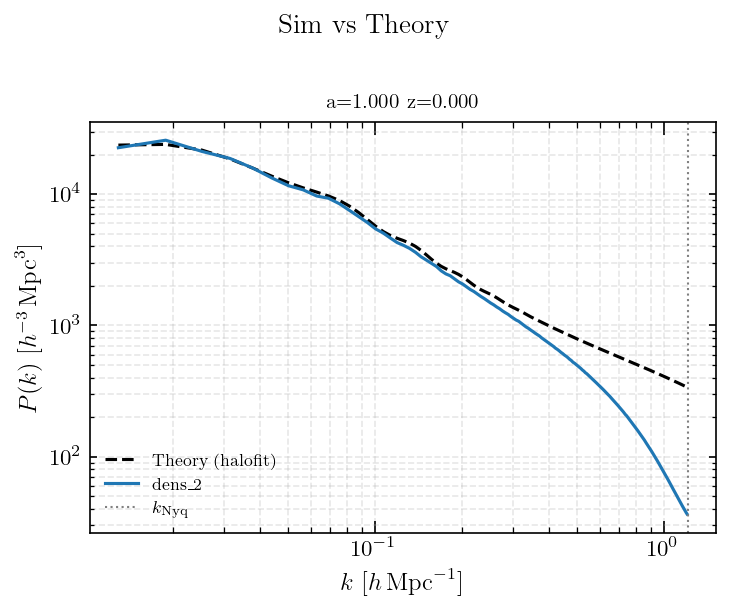

In [14]:
# --- Overlay: sim + theory ---
fig, axes = plt.subplots(1, n_snaps,
                         figsize=(5 * n_snaps, 4),
                         squeeze=False)
for i in range(n_snaps):
    ax  = axes[0, i]
    pk_i = pk0_arr[i] if pk0_arr.shape[0] > 1 else pk0_arr[0]
    th_i = theory_pks[i]

    ax.loglog(k, th_i,  color="black",    ls="--", lw=1.5, label=f"Theory ({NONLINEAR_FN})")
    ax.loglog(k, pk_i,  color="tab:blue", lw=1.5, label=catalogs[0]["label"])

    if box is not None:
        ax.axvline(k_nyq, color="gray", ls=":", lw=1, label=r"$k_{\rm Nyq}$")

    ax.grid(True, which="both", ls="--", alpha=0.3)
    ax.set_xlabel(r"$k\;[h\,\mathrm{Mpc}^{-1}]$")
    ax.set_ylabel(r"$P(k)\;[h^{-3}\,\mathrm{Mpc}^3]$")
    a_i = float(sf[i]) if i < len(sf) else 1.0
    z_i = float(zs[i]) if i < len(zs) else 0.0
    ax.set_title(f"a={a_i:.3f}  z={z_i:.3f}", fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle("Sim vs Theory", y=1.01)
fig.tight_layout()
# fig.savefig("output/density3d_pk_theory.png", dpi=150, bbox_inches="tight")
plt.show()

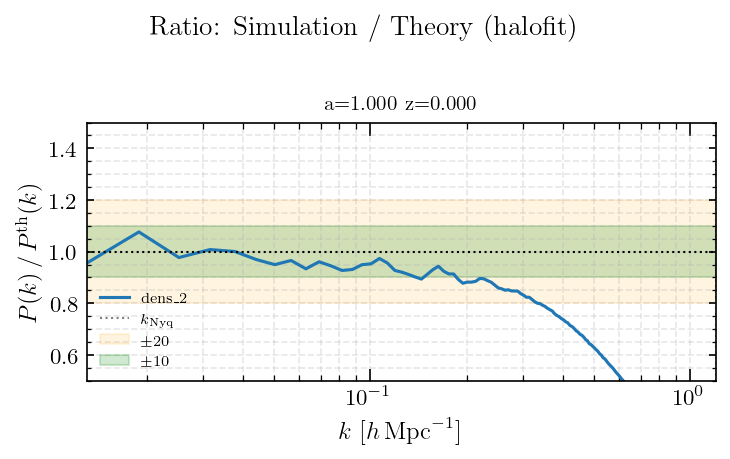

In [15]:
# Ratio P(k) / P(k)_theory
fig, axes = plt.subplots(1, n_snaps,
                         figsize=(5 * n_snaps, 3),
                         squeeze=False)
for i in range(n_snaps):
    ax  = axes[0, i]
    pk_i = pk0_arr[i] if pk0_arr.shape[0] > 1 else pk0_arr[0]
    th_i = theory_pks[i]
    ratio = pk_i / th_i

    ax.semilogx(k, ratio, color="tab:blue", lw=1.5, label=catalogs[0]["label"])
    ax.axhline(1.0, color="black", ls=":", lw=1)

    if box is not None:
        ax.axvline(k_nyq, color="gray", ls=":", lw=1, label=r"$k_{\rm Nyq}$")

    for pct, color, alpha in [(0.20, "orange", 0.12), (0.10, "green", 0.18)]:
        ax.fill_between(k, 1 - pct, 1 + pct, alpha=alpha, color=color,
                        label=f"±{int(pct*100)}%")

    ax.set_xlim(k[0], k[-1])
    ax.set_ylim(0.5, 1.5)
    ax.set_xlabel(r"$k\;[h\,\mathrm{Mpc}^{-1}]$")
    ax.set_ylabel(r"$P(k)\,/\,P^{\rm th}(k)$")
    a_i = float(sf[i]) if i < len(sf) else 1.0
    z_i = float(zs[i]) if i < len(zs) else 0.0
    ax.set_title(f"a={a_i:.3f}  z={z_i:.3f}", fontsize=10)
    ax.grid(True, which="both", ls="--", alpha=0.3)
    ax.legend(fontsize=7, loc="lower left")

fig.suptitle(f"Ratio: Simulation / Theory ({NONLINEAR_FN})", y=1.01)
fig.tight_layout()
# fig.savefig("output/density3d_ratio.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Multi-catalog Comparison

Add more paths to `PATHS` in the configuration cell to activate this section.  
All catalogs must be `DensityField` with the same mesh and box size.

In [16]:
if len(catalogs) < 2:
    print("Only one catalog loaded — add more paths to PATHS for comparison.")
else:
    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

    # --- Overlay P(k) ---
    fig, axes = plt.subplots(1, n_snaps,
                             figsize=(5 * n_snaps, 4),
                             squeeze=False)
    for i in range(n_snaps):
        ax = axes[0, i]
        for ci, (entry, pk) in enumerate(zip(catalogs, all_pks)):
            pk_arr = np.asarray(pk.array)
            if pk_arr.ndim == 1:
                pk_arr = pk_arr[np.newaxis]
            pk_i = pk_arr[i] if pk_arr.shape[0] > 1 else pk_arr[0]
            lbl = entry["label"] + (" [Ref]" if ci == 0 else "")
            ax.loglog(k, pk_i, color=colors[ci % len(colors)], lw=1.5, label=lbl)
        if box is not None:
            ax.axvline(k_nyq, color="gray", ls=":", lw=1)
        ax.grid(True, which="both", ls="--", alpha=0.3)
        ax.set_xlabel(r"$k\;[h\,\mathrm{Mpc}^{-1}]$")
        ax.set_ylabel(r"$P(k)$")
        a_i = float(sf[i]) if i < len(sf) else 1.0
        z_i = float(zs[i]) if i < len(zs) else 0.0
        ax.set_title(f"a={a_i:.3f}  z={z_i:.3f}", fontsize=10)
        if i == 0:
            ax.legend(fontsize=7)

    fig.suptitle("Multi-catalog P(k) overlay", y=1.01)
    fig.tight_layout()
    plt.show()

    # --- Ratio vs first catalog ---
    ref_pk_arr = np.asarray(all_pks[0].array)
    if ref_pk_arr.ndim == 1:
        ref_pk_arr = ref_pk_arr[np.newaxis]

    fig2, axes2 = plt.subplots(1, n_snaps,
                               figsize=(5 * n_snaps, 3),
                               squeeze=False)
    for i in range(n_snaps):
        ax = axes2[0, i]
        ref_i = ref_pk_arr[i] if ref_pk_arr.shape[0] > 1 else ref_pk_arr[0]
        for ci, (entry, pk) in enumerate(zip(catalogs[1:], all_pks[1:]), 1):
            pk_arr = np.asarray(pk.array)
            if pk_arr.ndim == 1:
                pk_arr = pk_arr[np.newaxis]
            pk_i  = pk_arr[i] if pk_arr.shape[0] > 1 else pk_arr[0]
            ratio = pk_i / ref_i
            ax.semilogx(k, ratio, color=colors[ci % len(colors)], lw=1.5, label=entry["label"])
        ax.axhline(1.0, color="black", ls=":", lw=1)
        if box is not None:
            ax.axvline(k_nyq, color="gray", ls=":", lw=1)
        for pct, alpha in [(0.10, 0.18), (0.05, 0.30)]:
            ax.fill_between(k, 1 - pct, 1 + pct, alpha=alpha, color="gray")
        ax.set_xlim(k[0], k[-1])
        ax.set_ylim(0.8, 1.2)
        ax.set_xlabel(r"$k\;[h\,\mathrm{Mpc}^{-1}]$")
        ax.set_ylabel(rf"$P(k)\,/\,P^{{\mathrm{{{catalogs[0]['label']}}}}}(k)$")
        a_i = float(sf[i]) if i < len(sf) else 1.0
        z_i = float(zs[i]) if i < len(zs) else 0.0
        ax.set_title(f"a={a_i:.3f}  z={z_i:.3f}", fontsize=10)
        ax.grid(True, which="both", ls="--", alpha=0.3)
        if i == 0:
            ax.legend(fontsize=7)

    fig2.suptitle(f"Ratio vs {catalogs[0]['label']}", y=1.01)
    fig2.tight_layout()
    plt.show()

Only one catalog loaded — add more paths to PATHS for comparison.
